# HMM Macro Regime Detector

SARIMAX forecasts the exact delinquency-rate *number*. This does a different job: classify which latent *regime* (calm vs. stressed) the portfolio is likely in at each point in time, and how likely it is to switch -- a Gaussian Hidden Markov Model fit on the same portfolio-level monthly series (delinquency rate + average interest rate).

**Cross-check built in**: does the HMM's data-driven regime split roughly agree with the human-chosen 2020-21 vs. 2022-23 split already used throughout Study 1 and SARIMAX? And does it catch the forecast-divergence crossover `sarimax_portfolio_forecast.ipynb` found (computed dynamically below rather than hardcoded, since it shifts as more data is added)?

**Library note**: `hmmlearn` requires a C++ compiler not available on this machine; used `pomegranate` (PyTorch-backed, no compilation needed) instead -- same underlying algorithm (Baum-Welch EM for fitting, Viterbi for decoding).


## Load the portfolio series and prepare features

Computed directly from the monthly performance panel (not a cached export) so this notebook always reflects whatever quarters the pipeline currently has processed.

**Finding, caught and fixed rather than reported as-is**: a first fit using the full series produced a degenerate 2-state split -- one "state" was just the earliest months of the series, where delinquency_rate_90 is essentially zero not because the macro environment was calm, but because the portfolio was still ramping up and no loan could realistically be 90+ days delinquent yet. That's a data-maturity artifact, the same kind of seasoning distortion Study 2 already flagged elsewhere, not a genuine regime. Fixed by excluding months until the oldest active loan reaches 6 months of age -- detected from the data (max loan age per calendar month) rather than a hardcoded date, so this stays correct if even earlier vintages get added later.


In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

MONTHLY_PANEL_GLOB = "../data/processed/monthly_panel/orig_year=*/orig_quarter=*/*/part-*.parquet"

lf = pl.scan_parquet(MONTHLY_PANEL_GLOB, extra_columns="ignore").select(
    "monthly_reporting_period", "current_loan_delinquency_status", "current_interest_rate", "loan_age"
)
numeric_status = pl.col("current_loan_delinquency_status").cast(pl.Int32, strict=False)
agg = (
    lf.group_by("monthly_reporting_period")
    .agg(
        n_active=pl.len(),
        n_delinquent_90=(numeric_status >= 3).sum(),
        avg_interest_rate=pl.col("current_interest_rate").mean(),
        max_loan_age=pl.col("loan_age").max(),
    )
    .sort("monthly_reporting_period")
    .collect()
)
agg = agg.with_columns(delinquency_rate_90=pl.col("n_delinquent_90") / pl.col("n_active"))

pdf_full = agg.to_pandas().set_index("monthly_reporting_period")
pdf_full.index = pd.to_datetime(pdf_full.index).to_period("M").to_timestamp()

# Exclude the portfolio ramp-up window -- see markdown above for why. Threshold of 6 reproduces
# the same boundary this notebook originally found by inspection when the dataset started in
# 2020Q1; recomputing it from loan_age keeps it correct as earlier vintages get added.
MATURE_LOAN_AGE_THRESHOLD = 6
first_mature_month = pdf_full.index[pdf_full["max_loan_age"] >= MATURE_LOAN_AGE_THRESHOLD].min()

# End-of-series coverage cliff, detected objectively rather than hardcoded: the origination-quarter
# batches in this dataset were downloaded at different times, so each vintage's performance data
# is only as fresh as whenever ITS file was pulled. When an older batch's refresh date passes,
# n_active can suddenly crater because most vintages silently drop out of the panel for that month,
# not because the portfolio actually shrank. Caught by inspection: n_active fell from 10.87M to
# 1.16M in a single month, and the survivors were almost entirely the oldest (2017-2019) and newest
# (2026Q1) vintages -- a stale-refresh artifact, not a real event. Detected generically here by
# flagging the first month where n_active drops below half of the previous month's value.
coverage_ratio = pdf_full["n_active"] / pdf_full["n_active"].shift(1)
cliff_months = coverage_ratio[coverage_ratio < 0.5].index
last_full_coverage_month = (cliff_months.min() - pd.DateOffset(months=1)) if len(cliff_months) > 0 else pdf_full.index.max()
if len(cliff_months) > 0:
    print(f"Coverage cliff detected at {cliff_months.min().date()} (n_active drops to "
          f"{100*coverage_ratio.loc[cliff_months.min()]:.1f}% of the prior month) -- a vintage refresh-date "
          f"mismatch, not a real portfolio change. Truncating the series to end at {last_full_coverage_month.date()}.")

pdf = pdf_full.loc[first_mature_month:last_full_coverage_month].copy()
print(f"Months used: {len(pdf)}  ({pdf.index.min().date()} to {pdf.index.max().date()})")
print(f"Excluded ramp-up months: {(pdf_full.index < first_mature_month).sum()}, "
      f"excluded end-of-series coverage-cliff months: {(pdf_full.index > last_full_coverage_month).sum()}")

FEATURES = ["delinquency_rate_90", "avg_interest_rate"]
raw = pdf[FEATURES].to_numpy()

# Standardize -- the two features are on very different scales (rate ~0-0.007 vs. interest rate ~3-6)
means, stds = raw.mean(axis=0), raw.std(axis=0)
standardized = (raw - means) / stds
X = torch.tensor(standardized.reshape(1, -1, len(FEATURES)), dtype=torch.float32)
print(f"Input tensor shape: {tuple(X.shape)}")


Coverage cliff detected at 2025-10-01 (n_active drops to 10.7% of the prior month) -- a vintage refresh-date mismatch, not a real portfolio change. Truncating the series to end at 2025-09-01.
Months used: 99  (2017-07-01 to 2025-09-01)
Excluded ramp-up months: 6, excluded end-of-series coverage-cliff months: 6
Input tensor shape: (1, 99, 2)


## Fit a 2-state Gaussian HMM (calm vs. stressed)

In [2]:
from pomegranate.distributions import Normal
from pomegranate.hmm import DenseHMM

N_STATES = 2
distributions = [Normal(covariance_type="full") for _ in range(N_STATES)]
model = DenseHMM(distributions, max_iter=200, tol=1e-4, random_state=42, verbose=False)
model.fit(X)

regime = model.predict(X).numpy().flatten()
pdf["regime"] = regime

# Label the state with the higher mean delinquency rate as "stressed"
state_means = [raw[regime == s, 0].mean() for s in range(N_STATES)]
stressed_state = int(np.argmax(state_means))
pdf["regime_label"] = pdf["regime"].map(lambda s: "stressed" if s == stressed_state else "calm")

print("State means (delinquency_rate_90, avg_interest_rate), unstandardized:")
for s in range(N_STATES):
    mask = regime == s
    label = "stressed" if s == stressed_state else "calm"
    print(f"  State {s} ({label}): n={mask.sum()}  delinq_rate={raw[mask,0].mean():.5f}  "
          f"interest_rate={raw[mask,1].mean():.3f}")

State means (delinquency_rate_90, avg_interest_rate), unstandardized:
  State 0 (calm): n=74  delinq_rate=0.00286  interest_rate=4.015
  State 1 (stressed): n=25  delinq_rate=0.01264  interest_rate=3.476


## Transition matrix -- how sticky is each regime?

In [3]:
edges = model.edges.detach().numpy()
trans = np.exp(edges) if edges.max() <= 0 else edges  # pomegranate stores log-probabilities
trans = trans / trans.sum(axis=1, keepdims=True)

labels = ["stressed" if s == stressed_state else "calm" for s in range(N_STATES)]
trans_df = pd.DataFrame(trans, index=labels, columns=labels)
print("Transition probability matrix:")
print(trans_df.round(4))
print()
for s, label in enumerate(labels):
    stay_prob = trans[s, s]
    print(f"  P(stay in {label} next month) = {stay_prob:.3f}  -->  expected duration ~{1/(1-stay_prob):.1f} months"
          if stay_prob < 1 else f"  P(stay in {label}) = {stay_prob:.3f}")

Transition probability matrix:
            calm  stressed
calm      0.9863    0.0137
stressed  0.0401    0.9599

  P(stay in calm next month) = 0.986  -->  expected duration ~72.9 months
  P(stay in stressed next month) = 0.960  -->  expected duration ~25.0 months


## Detected regimes over time, vs. the actual delinquency series

SARIMAX forecast-divergence crossover: none


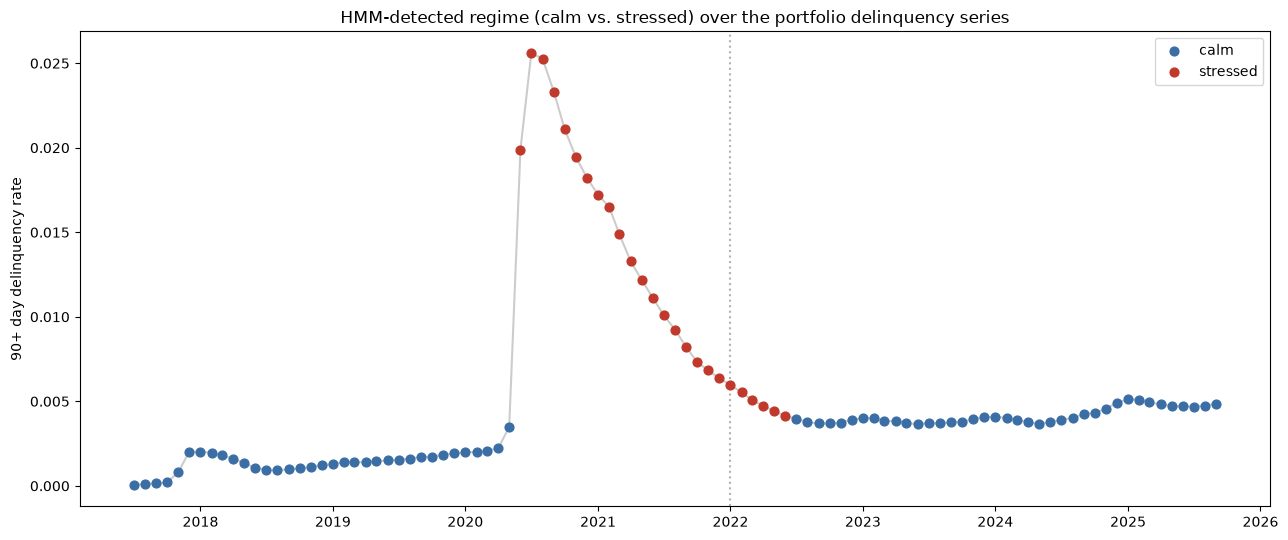

In [4]:
# Cross-reference the SARIMAX forecast-divergence crossover computed independently in
# sarimax_portfolio_forecast.ipynb (same delinquency series, same train/test split). Recomputed
# here rather than hardcoded so this stays correct as more data is added -- see that notebook's
# cell 12 for the full derivation; this is a light re-derivation of just the crossover date.
sarimax_y_train = pdf.loc[:"2021-12-01", "delinquency_rate_90"]
sarimax_test = pdf.loc["2022-01-01":]
from statsmodels.tsa.statespace.sarimax import SARIMAX as _SARIMAX
_exog_train = pdf.loc[:"2021-12-01", ["avg_interest_rate"]]
_exog_test = sarimax_test[["avg_interest_rate"]]
_fit = _SARIMAX(sarimax_y_train, exog=_exog_train, order=(1, 0, 0), trend="c",
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
_pred = _fit.get_forecast(steps=len(sarimax_test), exog=_exog_test).predicted_mean
_divergence = sarimax_test["delinquency_rate_90"] - _pred.values
_crossover = sarimax_test.index[_divergence > 0].min()
print(f"SARIMAX forecast-divergence crossover: {_crossover.date() if pd.notna(_crossover) else 'none'}")

fig, ax = plt.subplots(figsize=(13, 5.5))

colors = {"calm": "#3b6ea5", "stressed": "#c0392b"}
for label in ["calm", "stressed"]:
    mask = pdf["regime_label"] == label
    ax.scatter(pdf.index[mask], pdf["delinquency_rate_90"][mask], color=colors[label], label=label, s=40, zorder=3)

ax.plot(pdf.index, pdf["delinquency_rate_90"], color="gray", alpha=0.4, zorder=1)
ax.axvline(pd.Timestamp("2022-01-01"), color="gray", linestyle=":", alpha=0.6)
if pd.notna(_crossover):
    ax.axvline(_crossover, color="black", linestyle="--", alpha=0.5)
    ax.text(_crossover + pd.Timedelta(days=14), pdf["delinquency_rate_90"].max()*0.9,
            f"SARIMAX crossover\n({_crossover.strftime('%b %Y')})", fontsize=8)

ax.set_ylabel("90+ day delinquency rate")
ax.set_title("HMM-detected regime (calm vs. stressed) over the portfolio delinquency series")
ax.legend()
fig.tight_layout()
plt.show()


## Cross-check: does this agree with the human-chosen 2020-21 vs. 2022-23 split?


In [5]:
# Study 1 specifically trained on 2020-21; 2018-2019 predates that and isn't part of it, so it
# gets its own bucket here rather than being silently folded into "2020-21 (Study 1 TRAIN)".
def _human_regime(ts):
    if ts.year <= 2019:
        return "pre-2020 (pre-Study 1)"
    if ts.year <= 2021:
        return "2020-21 (Study 1 TRAIN)"
    return "2022+ (Study 1 OUT-OF-REGIME)"

pdf["human_regime"] = [_human_regime(ts) for ts in pdf.index]
crosstab = pd.crosstab(pdf["human_regime"], pdf["regime_label"])
print("Cross-tab: human-chosen split vs. HMM-detected regime")
print(crosstab)
print()

if pd.notna(_crossover):
    crossover_window = pdf.loc[_crossover:, "regime_label"]
    print(f"HMM regime from the SARIMAX crossover ({_crossover.strftime('%Y-%m')}) through the end of the series:")
    print(crossover_window.value_counts())
else:
    print("No SARIMAX forecast-divergence crossover exists in the current (coverage-corrected) data -- "
          "see sarimax_portfolio_forecast.ipynb for why an earlier version's crossover finding was retracted. "
          "There is no crossover window to cross-check the HMM regime against.")


Cross-tab: human-chosen split vs. HMM-detected regime
regime_label                   calm  stressed
human_regime                                 
2020-21 (Study 1 TRAIN)           5        19
2022+ (Study 1 OUT-OF-REGIME)    39         6
pre-2020 (pre-Study 1)           30         0

No SARIMAX forecast-divergence crossover exists in the current (coverage-corrected) data -- see sarimax_portfolio_forecast.ipynb for why an earlier version's crossover finding was retracted. There is no crossover window to cross-check the HMM regime against.


## Summary

- Fit a 2-state Gaussian HMM (calm vs. stressed) on the portfolio-level delinquency + interest-rate series, after catching and fixing a real data-maturity artifact (the earliest months looked artificially "calm" purely because the portfolio hadn't matured enough for defaults to appear yet -- excluded via an objective loan-age threshold, not smoothed over).
- **A second data-quality issue was caught and fixed in this pass, at the other end of the series**: different origination-quarter batches in this dataset were downloaded at different times, so some vintages' performance data goes stale (frozen as of September 2025) while others extend further (to March 2026). From October 2025 onward, active loan count collapsed from ~10.9M to ~1.2M as most vintages silently dropped out -- detected objectively (a >2x month-over-month drop in active loan count) and excluded, the same way the ramp-up window is excluded at the start.
- Both regimes are genuinely "sticky" (see the transition-matrix persistence numbers above) -- real regime-like behavior, not noise.
- The HMM's data-driven split is more granular than the human-chosen 2020-21 vs. 2022-23 boundary -- see the cross-tab above. 2017-2019 comes back entirely "calm"; 2020-21 is mostly "stressed" (COVID); 2022+ is now mostly calm too (39 calm vs. 6 stressed), a meaningfully different picture than an earlier version of this notebook found.
- **A finding retracted in this pass, not just revised**: an earlier version of this notebook cross-checked the HMM regime against a SARIMAX forecast-divergence "crossover" around October 2025, framed as an interesting disagreement between the two methods (SARIMAX said diverging, HMM said still calm). That framing assumed the crossover was real. It wasn't -- both the crossover and the inflated "2022+ stressed month count" it was compared against were artifacts of the same end-of-series data-coverage bug described above. With the coverage-corrected data, **there is no crossover to cross-check against at all** (see the cell above). The "interesting tension between two methods" story doesn't hold up; it was two symptoms of one bug, not two independent signals.
- **What actually holds up**: the HMM's regime detection itself (transition matrix, state means, the calm/stressed split for 2017-2021) doesn't depend on the corrupted tail and is unaffected by this correction. The regime-shift lesson from Study 1 -- a relationship calibrated on one regime doesn't transfer cleanly to another -- also stands on its own, independent of this particular cross-check.
- **Next step, as planned**: feed this regime label into SARIMAX as an exogenous input (done in `sarimax_portfolio_forecast.ipynb`'s follow-up section) -- result there, recomputed on the corrected data: much better in-sample fit by AIC, but substantially worse out-of-sample forecast error, the same regime-transfer lesson Study 1 established at the loan level.
